In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Loaded")

Loaded


In [2]:
df = pd.read_csv('games.csv')
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [3]:
df.keys()

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements',
       'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories',
       'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='object')

The CSV files has broken header. The header row has 39 names, but every data row has 40 values, seems like because the csv merged Discount and DLC count into one header name DiscountDLC count

In [4]:
# Splitting DLC count and Discount
df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

print("Done")

# got the error of length mismatch. so instead of adding one more col, I just drop the AppID cause it doesnt seem like it is needed for the prediction

Done


In [5]:
pd.set_option('display.max_columns', None)
df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,http://mangagamer.org/supipara,http://mangagamer.com,support@mangagamer.com,True,False,False,0,NaN,0,252,3,NaN,0,231,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",[],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,support@8floor.net,True,True,False,0,NaN,0,21,3,NaN,0,0,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],['Korean'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,yujingamesc@gmail.com,True,False,False,0,NaN,0,0,0,NaN,19,0,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,https://www.realityexpanded.com/books-games,https://www.realityexpanded.com,support@realityexpanded.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [6]:
# structure of the dataset
# most common value in that column
def top_val(s):
    vc = s.value_counts(dropna=True)
    return str(vc.index[0])[:22] if len(vc) else '(all null)'

# what percentage of all 125855 rows have this value
def top_pct(s):
    vc = s.value_counts(dropna=True)
    return round(vc.iloc[0] / len(s) * 100, 2) if len(vc) else 0.0

overview = pd.DataFrame({
    'dtype'      : df.dtypes,
    'null'       : df.isna().sum(),
    'pct_filled' : (df.notna().mean() * 100).round(2),
    'n_unique'   : df.nunique(dropna=True),
    'top_value'  : df.apply(top_val),
    'top_pct'    : df.apply(top_pct),
})

print(overview.sort_values('top_pct', ascending=False).to_string())

                              dtype    null  pct_filled  n_unique               top_value  top_pct
Windows                        bool       0      100.00         2                    True    99.97
User score                    int64       0      100.00        31                       0    99.97
Required age                  int64       0      100.00        15                       0    98.98
Median playtime two weeks     int64       0      100.00       999                       0    96.86
Average playtime two weeks    int64       0      100.00       995                       0    96.86
Metacritic score              int64       0      100.00        73                       0    96.62
Linux                          bool       0      100.00         2                   False    87.23
DLC count                     int64       0      100.00       117                       0    85.67
Peak CCU                      int64       0      100.00      1110                       0    84.36
Recommenda

top_pct tell me that if the data worth to add in regardless of how full it is.
So from here I kinda know what to drop and what to use to answer the questions of the client. 

But hold on I'll come back to this later. 

The client stated in the success criteria that "Defines and justifies an ownership-based success threshold based on the observed ownership distribution." and in the dataset limitation the client mentioned "Estimated ownership is reported as a range rather than an exact figure, and most games occupy the lowest ownership bucket". So all of this shows in the Estimated Owners col. So we'll start from here.

In [11]:
owners = df['Estimated owners'].value_counts()
key = lambda s: (int(s.split(' - ')[0]), int(s.split(' - ')[1]))
order = sorted(owners.index, key=key)
owners = owners[order]
print(owners)

Estimated owners
0 - 0                    24579
0 - 20000                75705
20000 - 50000            11397
50000 - 100000            5355
100000 - 200000           3454
200000 - 500000           2856
500000 - 1000000          1155
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64


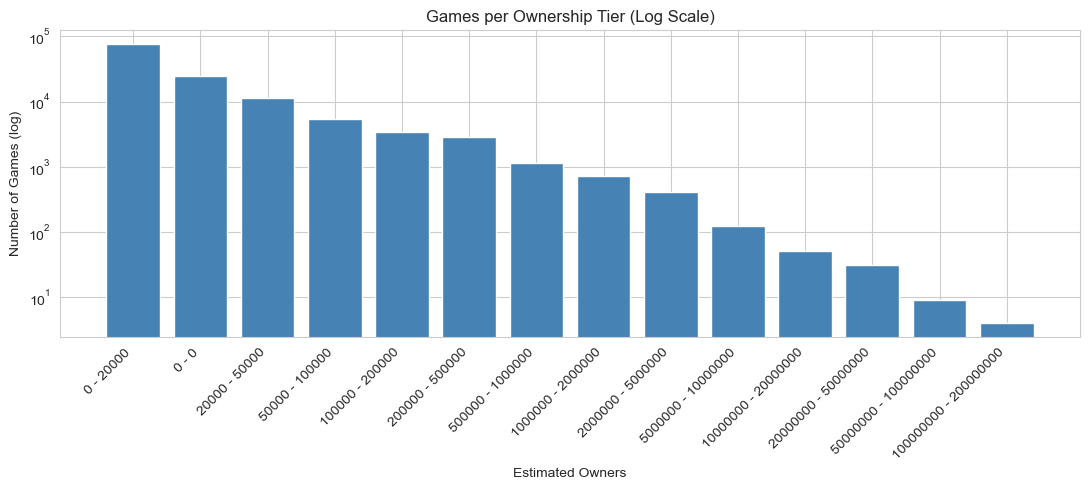

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(owners)), owners.values, color='steelblue')
ax.set_yscale('log')  # Log scale for y-axis
ax.set_xticks(range(len(owners)))
ax.set_xticklabels(owners.index, rotation=45, ha='right')
ax.set_title('Games per Ownership Tier (Log Scale)')
ax.set_xlabel('Estimated Owners')
ax.set_ylabel('Number of Games (log)')
plt.tight_layout()
plt.show()

so what these tell us about. the Estimated owners col sorts every game into one of 14 groups. there are 2 groups that hold almost everything. 0-0 (24579 + 0-20000 (75705) = 100284. it is about ~79.68% of the file. So about 8 out of every 10 games have 20000 owners or even fewer. The biggest single group is 0-200000 wih 75705 games like about 60.15% on its own.
The figure shows each group above is smaller than the one below. Like after the second group the counts only go down and never up (like a stair).
Also, very big games are actually very rare like games with 5000000 owners or more areabout 220 games (~0.175%). Literrally fewer than 2 games in every 1000. 

So from here I would pick the success line at 50000 owners or more (total will be about 14174 games ~11.26%)

So next is to look a bit more closer to 0-0 cause it seems there something hiding here.

In [17]:
df[df['Estimated owners'] == '0 - 0'].head(10)

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,Full audio languages,Reviews,Header image,Website,Support url,Support email,Windows,Mac,Linux,Metacritic score,Metacritic url,User score,Positive,Negative,Score rank,Achievements,Recommendations,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1946890,Codename: Warlock Playtest,"Mar 25, 2022",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2260230,Midnight Dash,"Jan 9, 2023",0 - 0,0,0,0.00,0,0,Story! The game tells you a story about Sean w...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,midnightdash.game@gmail.com,True,False,False,0,NaN,0,0,0,NaN,17,0,NaN,0,0,0,0,Saku Hållfast,Saku Hållfast,"Single-player,Multi-player,PvP,Shared/Split Sc...","Action,Adventure,Indie,Free To Play,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2713630,Black Market,"Jan 24, 2025",0 - 0,0,0,0.00,0,0,Black Market is an item shop simulator where y...,['English'],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,me@stevennosov.com,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,Wani Games LLC,Wani Games LLC,Single-player,"Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2349750,CyberVault Playtest,"Mar 8, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,3,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2628280,A Night In Omar's Burger Playtest,"Oct 4, 2023",0 - 0,0,0,0.00,0,0,NaN,[],[],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2731180,Blaster Multiplayer,"Jan 2, 2024",0 - 0,0,0,0.00,0,0,About This Game Overview: Immerse yourself in ...,"['English', 'French', 'Italian', 'German', 'Sp...","['English', 'Ukrainian']",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,https://github.com/gnorgol,NaN,True,False,False,0,NaN,0,0,0,NaN,0,0,This Game may contain content not appropriate ...,0,0,0,0,Guillaume Norgol,Guillaume Norgol,"Multi-player,PvP,Online PvP,Full controller su...",Action,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3854040,BRUTALISMUS: Dystopia,"Jul 31, 2025",0 - 0,0,0,1.39,0,1,Can you escape the structures of your own mind...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,NaN,NaN,dreamdealersteamfaq@gmail.com,True,True,True,0,NaN,0,0,0,NaN,1,0,NaN,0,0,0,0,ETERNIDAD,ETERNIDAD,"Single-player,Steam Achievements,Custom Volume...","Adventure,Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2310500,Ortheo's Interdimensional Jam Session,"Aug 10, 2023",0 - 0,0,0,0.00,0,0,Get ready to rock and groove with Ortheo's Int...,['English'],['English'],NaN,https://shared.akamai.steamstatic.com/store_it...,http://www.dallenlarson.com/,http://www.dallenlarson.com/,dallen@dallenlarson.com,True,True,False,0,NaN,0,0,0,NaN,13,0,NaN,0,0,0,0,Larsonsoft,Larsonsoft,"Single-player,Steam Achievements,Includes leve...","Action,Indie,Free To Play",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2641000,Spider-Guy: Trapped in the Cheese Place,"Feb 21, 2024",0 - 0,0,0,0.00,0,0,Spider-guy has been imprisoned by the dastardl...,"['English', 'French', 'Italian', 'German', 'Sp...","['En

In [19]:
CORE = ['Genres', 'Categories', 'Developers', 'Publishers', 'About the game']
is_listing_only = df[CORE].isna().all(axis=1)
print("no metadata at all :", is_listing_only.sum())
print("eligible games:", len(df) - is_listing_only.sum())
junk = df[is_listing_only]
print("\nhave Playtest in the name:",
      junk['Name'].str.contains('Playtest', case=False, na=False).sum())
print("\ntheir ownership tiers:")
print(junk['Estimated owners'].value_counts())

no metadata at all : 7983
eligible games: 117872

have Playtest in the name: 7858

their ownership tiers:
Estimated owners
0 - 0    7983
Name: count, dtype: int64


now we look for the success rate on the eligible games 

In [21]:
eli = df[~is_listing_only].copy()

owners_low = eli['Estimated owners'].str.split(' - ').str[0].astype(int)
eli['success'] = (owners_low >= 50_000).astype(int)

print("eligible   :", len(eli))
print("successful :", eli['success'].sum())
print("success rate: {:.2f}%".format(eli['success'].mean() * 100))

eligible   : 117872
successful : 14174
success rate: 12.02%


7983 rows are missing all five information columns. Of these, 7858 (98.4%)have Playtest in the name and all 7983 sit in the 0-0 owners group with no exceptions. A Playtest is a free test version not something anyone can buy so I removed them. That leaves 117872 games. Worth to note that I removed them for missing information not for having zero owners.

In [25]:
# Genres
# get the avg genres per games
genre_long = (eli[['success']]
              .join(eli['Genres'].fillna('').str.split(',').explode()
                    .str.strip().rename('genre'), how='right'))
genre_long = genre_long[genre_long['genre'] != '']
print("distinct genres:", genre_long['genre'].nunique())
print("avg genres per game:", round(len(genre_long) / eli['Genres'].notna().sum(), 2))

distinct genres: 33
avg genres per game: 2.88


In [26]:
by_genre =(genre_long.groupby('genre')['success']
            .agg(games='size', wins = 'sum', rate = 'mean'))
by_genre['rate_pct'] = (by_genre['rate'] * 100).round(2)
print("\nbase rate = 12.02%")
print(by_genre.drop(columns = 'rate').sort_values('games', ascending=False).to_string())


base rate = 12.02%
                       games  wins  rate_pct
genre                                       
Indie                  82884  8981     10.84
Casual                 51677  3997      7.73
Action                 47344  6537     13.81
Adventure              46293  5974     12.90
Simulation             24912  3106     12.47
Strategy               23058  3515     15.24
RPG                    21577  3548     16.44
Free To Play           12605  1672     13.26
Early Access           11572   932      8.05
Sports                  4971   515     10.36
Racing                  4169   490     11.75
Massively Multiplayer   2596   609     23.46
Utilities               1091    99      9.07
Design & Illustration    584    53      9.08
Animation & Modeling     484    42      8.68
Education                464    23      4.96
Violent                  414    35      8.45
Video Production         340    31      9.12
Game Development         323    24      7.43
Gore                     257    29 

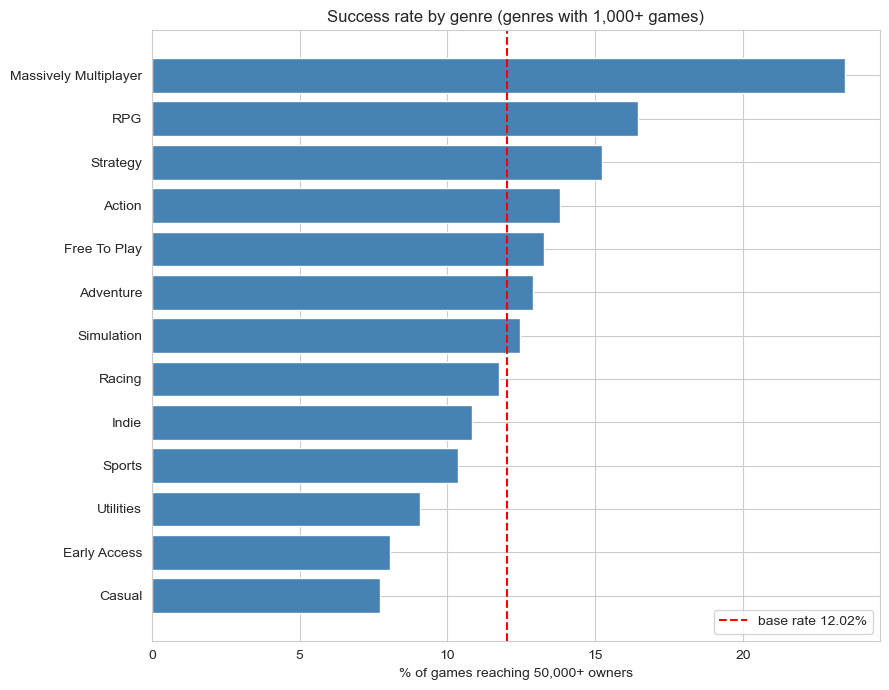

In [27]:
# visualization
plot = by_genre[by_genre['games'] >= 1000].sort_values('rate_pct')
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot.index, plot['rate_pct'], color='steelblue')
ax.axvline(12.02, color='red', linestyle='--', label='base rate 12.02%')
ax.set_xlabel('% of games reaching 50,000+ owners')
ax.set_title('Success rate by genre (genres with 1,000+ games)')
ax.legend()
plt.tight_layout()
plt.show()

Each game counts once for every genre it has. Only genres with more than 1000 games are shown since small genres can look good by luck alone. What I can see here is that the gao is real as the best genr Massively Multiplayer is about 3 times the worst Casual. This will later help to answer the question of the client taht if genre still matters after holding price, release
period and platforms steady.

In [28]:
# Price. It can be one of the most thing user consider when buying it
# Calculate the fraction of free games (in percent)

df_percent_free = df[df['Price'] == 0]['Estimated owners'].value_counts() / df['Estimated owners'].value_counts() * 100
df_wo_free = df[df['Price'] != 0]

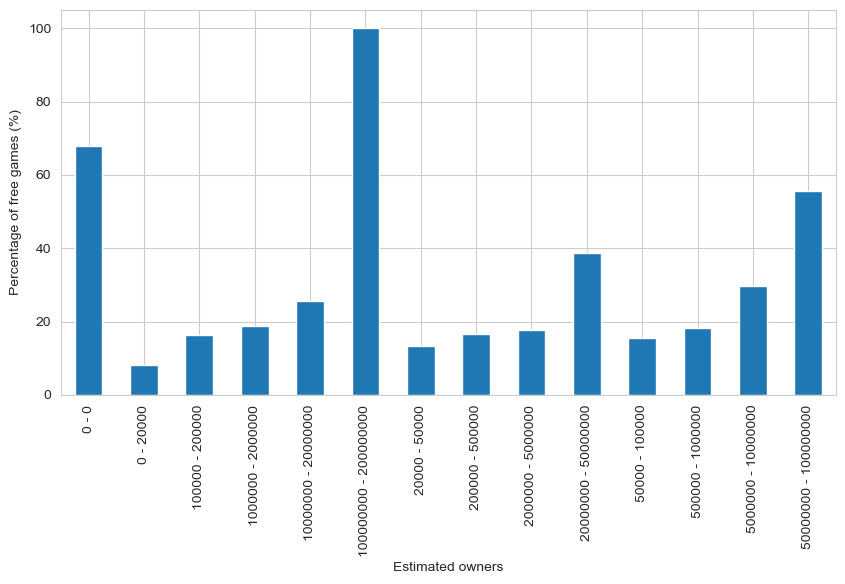

In [29]:
df_percent_free.plot.bar(ylabel='Percentage of free games (%)');

In [30]:
# some fixes need to be done
# need to sort on both numbers in the range, not on the string
key = lambda s: (int(s.split(' - ')[0]), int(s.split(' - ')[1]))

In [32]:
# all 7983 playtests are free and all sit in 0-0 so inflating from 52.6% to 68.0%
tot  = eli['Estimated owners'].value_counts()
free = eli[eli['Price'] == 0]['Estimated owners'].value_counts()
t = pd.DataFrame({'games': tot, 'free': free}).fillna(0)
t['pct_free'] = (t['free'] / t['games'] * 100).round(1)
t = t.loc[sorted(t.index, key=key)]
print(t.to_string())

                       games  free  pct_free
Estimated owners                            
0 - 0                  16596  8724      52.6
0 - 20000              75705  6072       8.0
20000 - 50000          11397  1527      13.4
50000 - 100000          5355   827      15.4
100000 - 200000         3454   563      16.3
200000 - 500000         2856   477      16.7
500000 - 1000000        1155   209      18.1
1000000 - 2000000        729   136      18.7
2000000 - 5000000        405    72      17.8
5000000 - 10000000       125    37      29.6
10000000 - 20000000       51    13      25.5
20000000 - 50000000       31    12      38.7
50000000 - 100000000       9     5      55.6
100000000 - 200000000      4     4     100.0


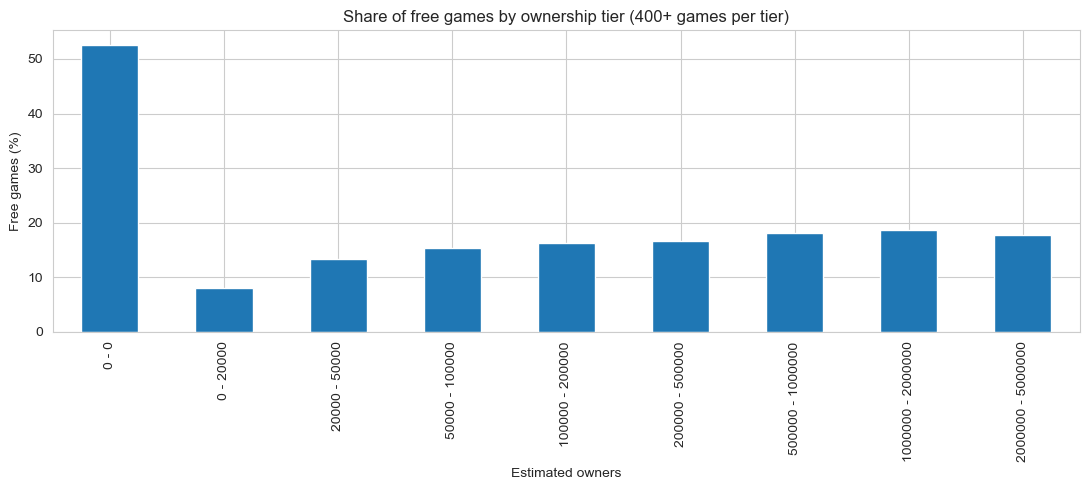

In [34]:
# need to drop last 5 groups to have the bars I can trust because with few games one single game moves the bar a lot
# in the 4 game groups one game is worth 25% point -> cant trust the bar
t_big = t[t['games'] >= 400]
t_big['pct_free'].plot.bar(ylabel='Free games (%)', figsize=(11, 5))
plt.title('Share of free games by ownership tier (400+ games per tier)')
plt.tight_layout()
plt.show()